# Cycle Count of Flash Attention

记录Flash Attention子算子在Rocket+Gemmini+Saturn架构下的运行周期数并可视化

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df = pd.read_excel(io="attention_cycles_cnt.xlsx", sheet_name="Sheet1", header=0, index_col=0)
df.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Gemmini采用默认INT8 WS配置 / Saturn VLEN=256", inplace=True)
df.drop(index="rowmax(S)\n(CPU)", inplace=True)
df.drop(index="exp(S - m)\n(CPU)", inplace=True)
df.drop(index="rowsum(P)\n(CPU)", inplace=True)
df.drop(index="normalization\n(CPU)", inplace=True)
df

,1x5,8x8,16x16,16x64,64x16,64x64,64x128,128x64,128x128,256x256
QK^T,1047.0,1230.0,1358.0,1282.0,1950.0,3895.0,7491.0,6079.0,10940.0,48537.0
PV,624.0,756.0,1009.0,1226.0,1711.0,3787.0,5940.0,6315.0,10590.0,25999.0
softmax(S)\n(RVV),477.0,3127.0,6664.0,11923.0,26356.0,46961.0,75170.0,93493.0,149269.0,533445.0
rowmax(S)\n(RVV),136.0,806.0,1619.0,2147.0,6385.0,8136.0,10255.0,15878.0,19296.0,52455.0
exp(S - m)\n(RVV),152.0,963.0,2072.0,6133.0,7967.0,24293.0,48477.0,48473.0,96943.0,396106.0
rowsum(P)\n(RVV),161.0,1075.0,2086.0,2289.0,7991.0,8905.0,10237.0,17761.0,20574.0,80068.0
normalization\n(RVV),40.0,381.0,706.0,1367.0,3120.0,3397.0,5070.0,6085.0,9831.0,43167.0


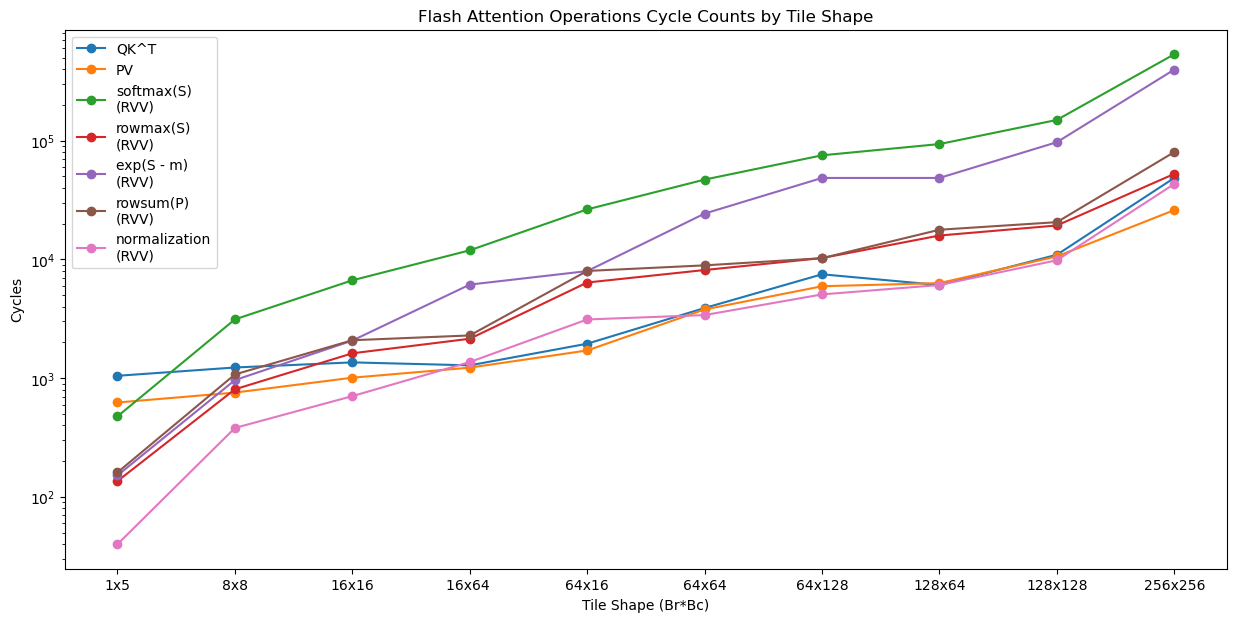

In [15]:
# 分操作可视化周期数
operations = df.index.tolist()
shapes = df.columns.tolist()
plt.figure(figsize=(15, 7))
for i, operation in enumerate(operations):
    plt.plot(shapes, df.loc[operation], marker='o', label=operation)

plt.yscale('log')
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts by Tile Shape")
plt.legend()

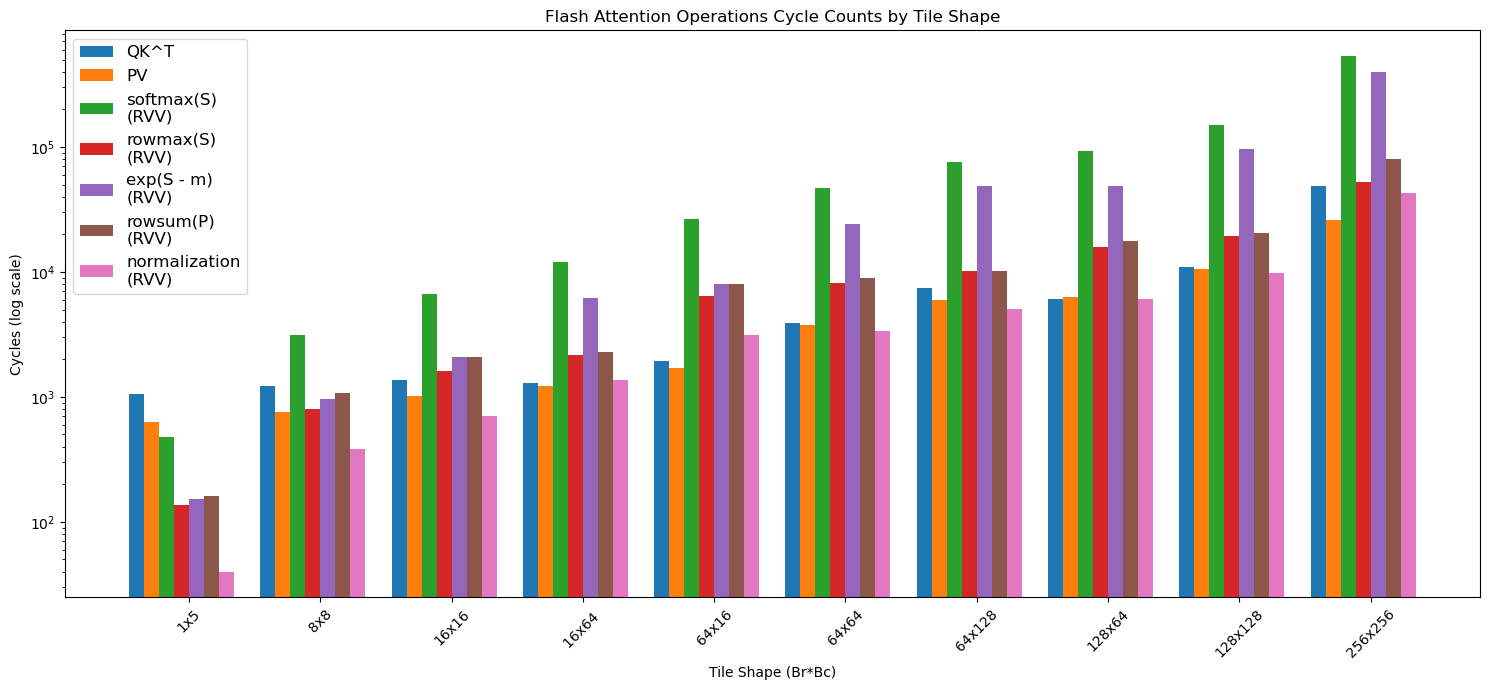

In [16]:
x = np.arange(len(shapes))
width = 0.8 / len(operations)

plt.figure(figsize=(15, 7))
for i, operation in enumerate(operations):
    plt.bar(x + i * width, df.loc[operation], width, label=operation)

plt.yscale('log')
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles (log scale)")
plt.title("Flash Attention Operations Cycle Counts by Tile Shape")
plt.xticks(x + width * len(operations) / 2, shapes, rotation=45)
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

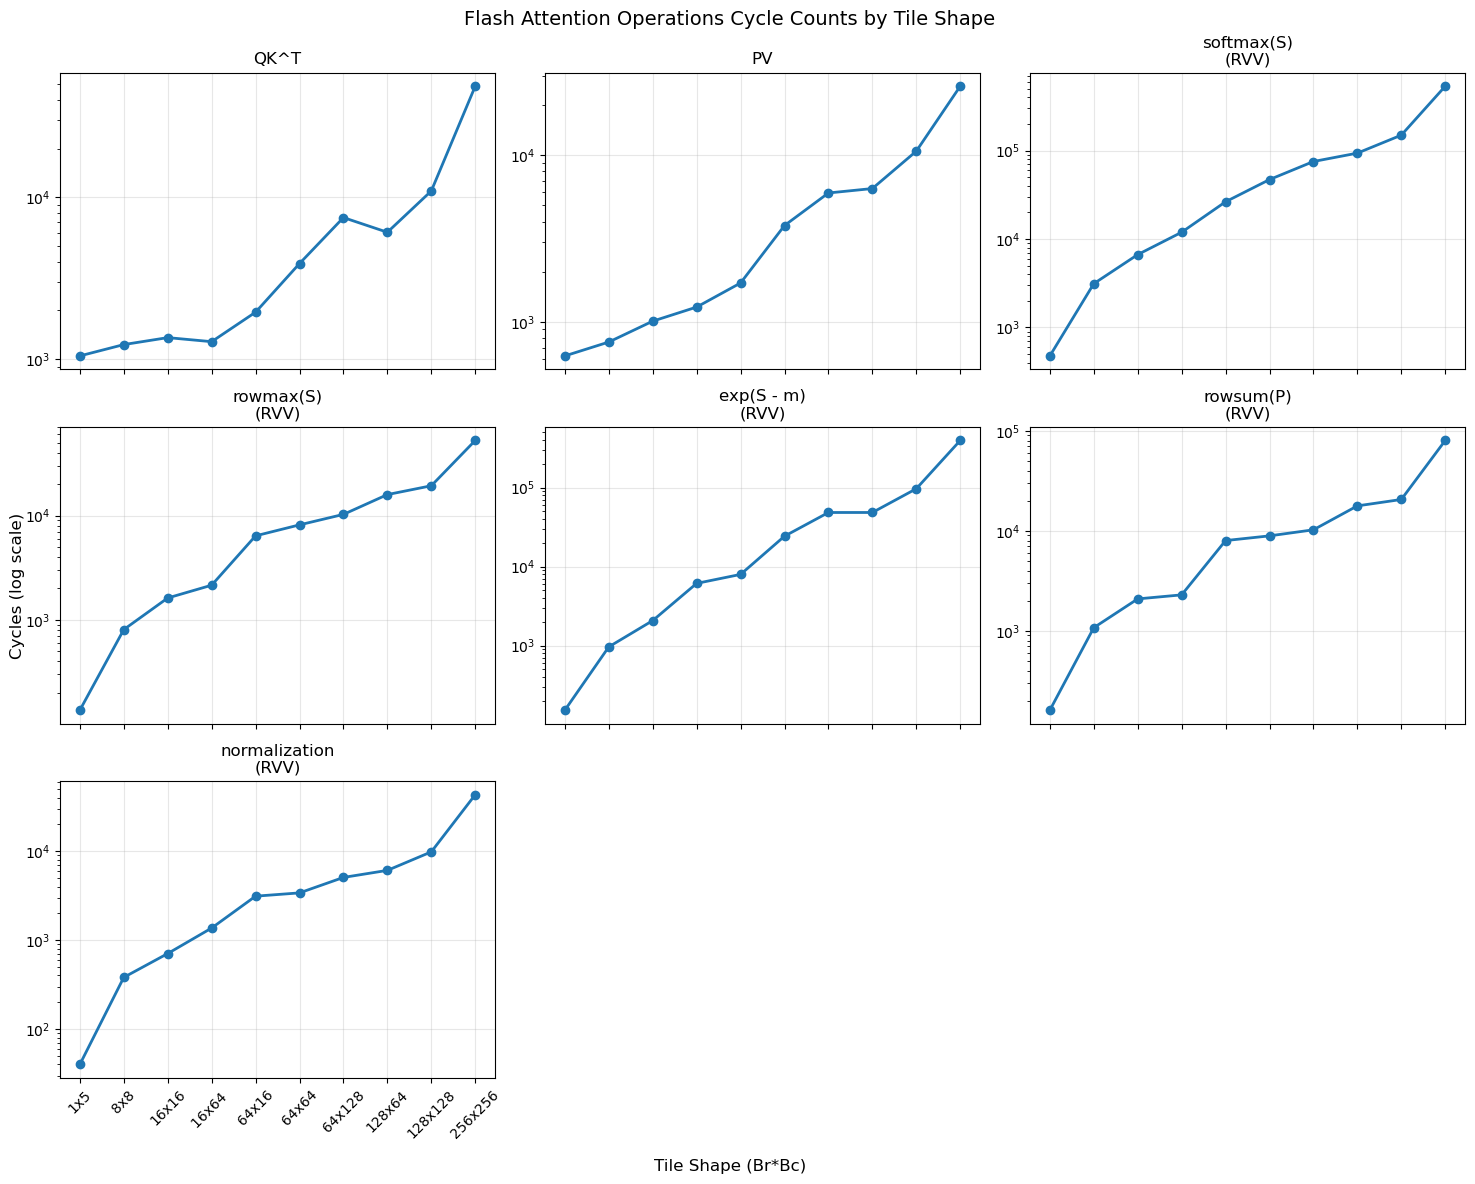

In [17]:
n_ops = len(operations)
cols = 3
rows = (n_ops + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=True)
axes = axes.flatten()

for i, operation in enumerate(operations):
    axes[i].plot(shapes, df.loc[operation], marker='o', linewidth=2)
    axes[i].set_title(operation)
    axes[i].set_yscale('log')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

# 隐藏多余子图
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.supxlabel("Tile Shape (Br*Bc)")
fig.supylabel("Cycles (log scale)")
fig.suptitle("Flash Attention Operations Cycle Counts by Tile Shape", fontsize=14)
plt.tight_layout()

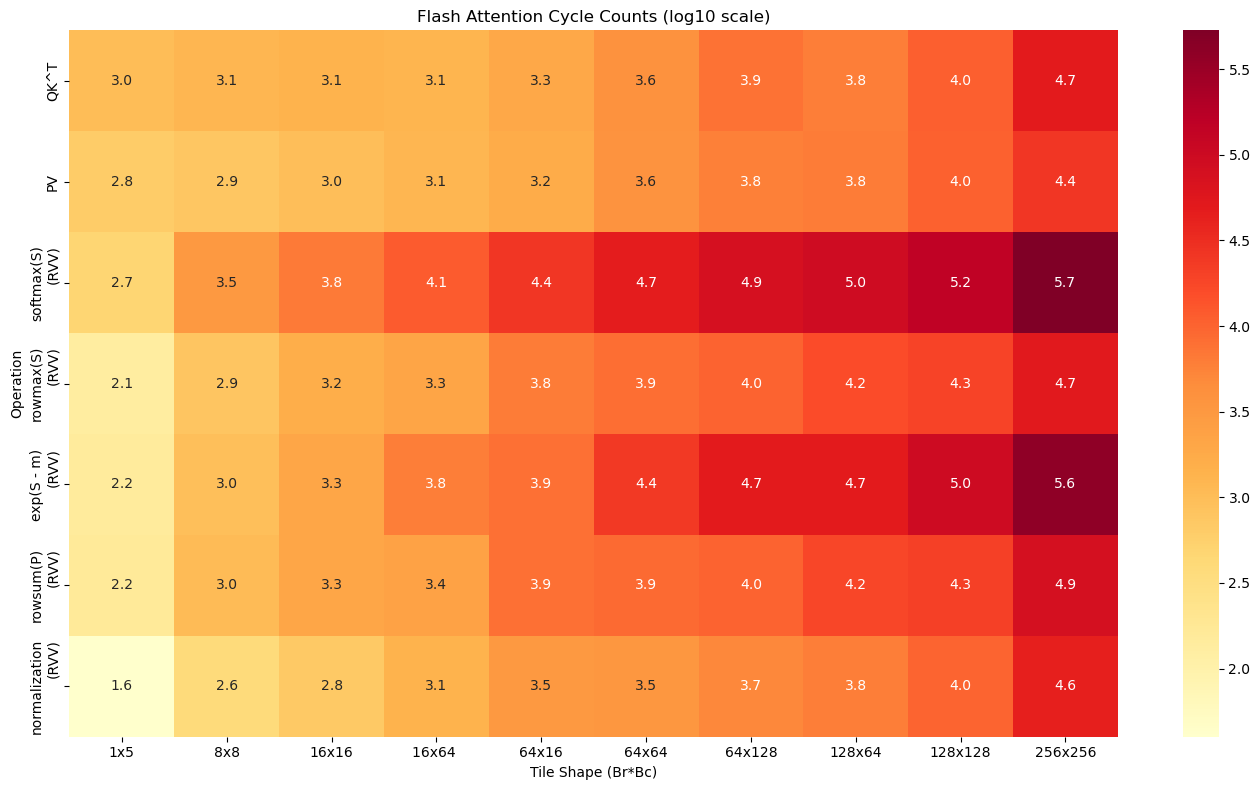

In [18]:
# 分操作可视化周期数 - 热力图
import seaborn as sns

plt.figure(figsize=(14, 8))
# 对数据取log便于显示
log_df = np.log10(df.astype(float))
sns.heatmap(log_df, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=df.columns.tolist(), yticklabels=df.index.tolist())
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Operation")
plt.title("Flash Attention Cycle Counts (log10 scale)")
plt.tight_layout()

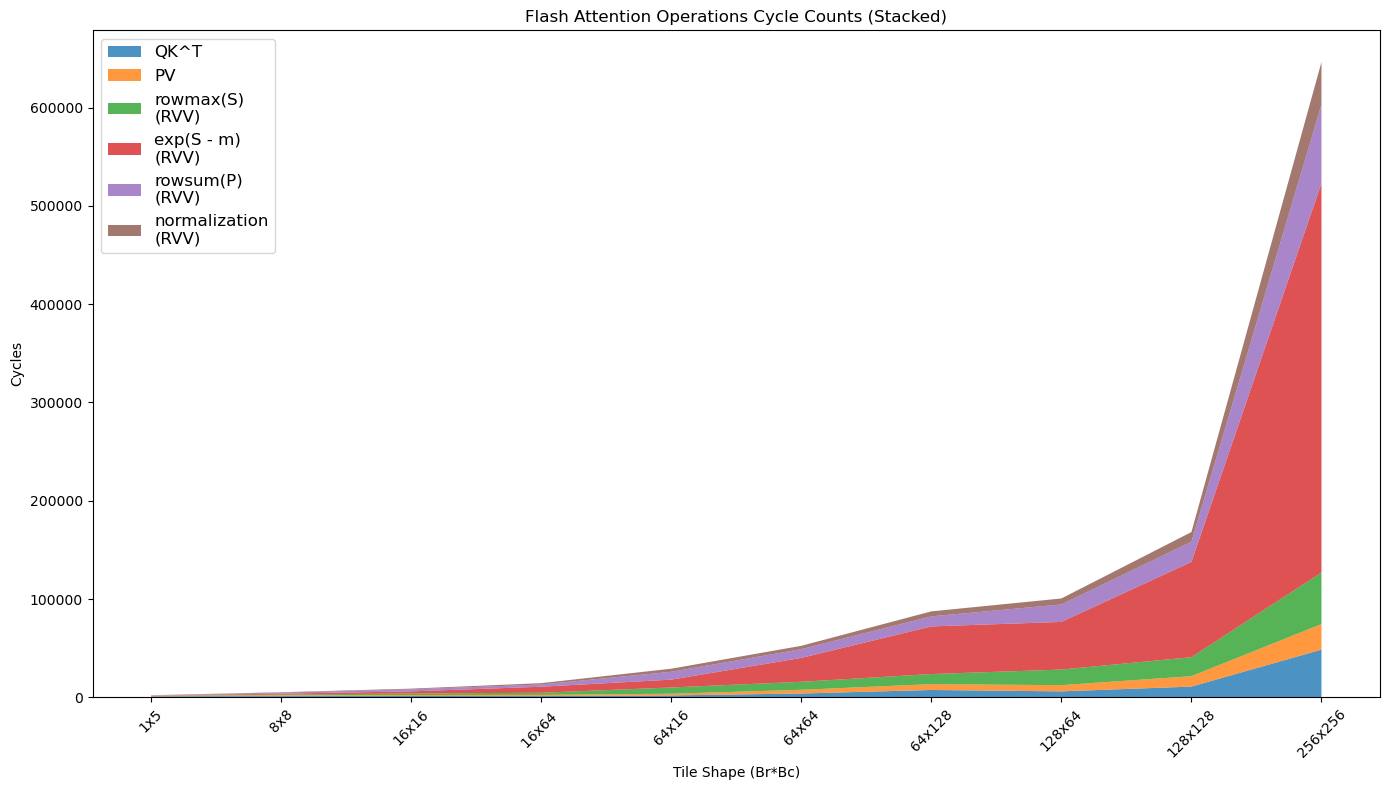

In [19]:
# 分操作可视化周期数 - 堆叠面积图
df_withoputSoftmax = df.drop(index="softmax(S)\n(RVV)",inplace=False)
operations = df_withoputSoftmax.index.tolist()
shapes = df_withoputSoftmax.columns.tolist()

plt.figure(figsize=(14, 8))
plt.stackplot(range(len(shapes)), [df_withoputSoftmax.loc[op] for op in operations], 
              labels=operations, alpha=0.8)
plt.xticks(range(len(shapes)), shapes, rotation=45)
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts (Stacked)")
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()